# FAERS Data Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')
%matplotlib inline

## Load Data

In [2]:
df = pd.read_csv('final_faers_data.csv', low_memory=False)
df.head()

,primaryid,fda_dt,age_grp,sex,reporter_country,occr_country,age_in_years,is_hcp,drug_sequence,drug_role,...,active_chemical,route,dechallenge,dose_amount,dose_form,reaction_term,indication_for_use,outcome_code,start_dt,therapy_status
0,41627247,20201124,Adult,UNK,GB,GB,59.0,True,1,PS,...,DIDANOSINE,Transplacental,Unknown,400.0,Unknown,Brain malformation,Product used for unknown indication,Congenital Anomaly,20040122.0,Completed
1,41627247,20201124,Adult,UNK,GB,GB,59.0,True,1,PS,...,DIDANOSINE,Transplacental,Unknown,400.0,Unknown,Brain malformation,Product used for unknown indication,Other Serious,20040122.0,Completed
2,41627247,20201124,Adult,UNK,GB,GB,59.0,True,1,PS,...,DIDANOSINE,Transplacental,Unknown,400.0,Unknown,Congenital central nervous system anomaly,Product used for unknown indication,Congenital Anomaly,20040122.0,Completed
3,41627247,20201124,Adult,UNK,GB,GB,59.0,True,1,PS,...,DIDANOSINE,Transplacental,Unknown,400.0,Unknown,Congenital central nervous system anomaly,Product used for unknown indication,Other Serious,20040122.0,Completed
4,41627247,20201124,Adult,UNK,GB,GB,59.0,True,1,PS,...,DIDANOSINE,Transplacental,Unknown,400.0,Unknown,Foetal exposure during pregnancy,Product used for unknown indication,Congenital Anomaly,20040122.0,Completed


## Data Overview



In [16]:
if not df.empty:
    print(df.info())
    print("\nNumerical Statistics:")
    print(df.describe())
    print("\nCategorical Statistics:")
    print(df.describe(include=['object', 'category', 'bool']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4635053 entries, 0 to 4635052
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   primaryid           int64  
 1   fda_dt              int64  
 2   age_grp             object 
 3   sex                 object 
 4   reporter_country    object 
 5   occr_country        object 
 6   age_in_years        float64
 7   is_hcp              bool   
 8   drug_sequence       int64  
 9   drug_role           object 
 10  drugname            object 
 11  active_chemical     object 
 12  route               object 
 13  dechallenge         object 
 14  dose_amount         float64
 15  dose_form           object 
 16  reaction_term       object 
 17  indication_for_use  object 
 18  outcome_code        object 
 19  start_dt            object 
 20  therapy_status      object 
dtypes: bool(1), float64(2), int64(3), object(15)
memory usage: 711.7+ MB
None

Numerical Statistics:
          primaryid       

## Univariate Analysis


### Distribution of Adverse Event Outcomes

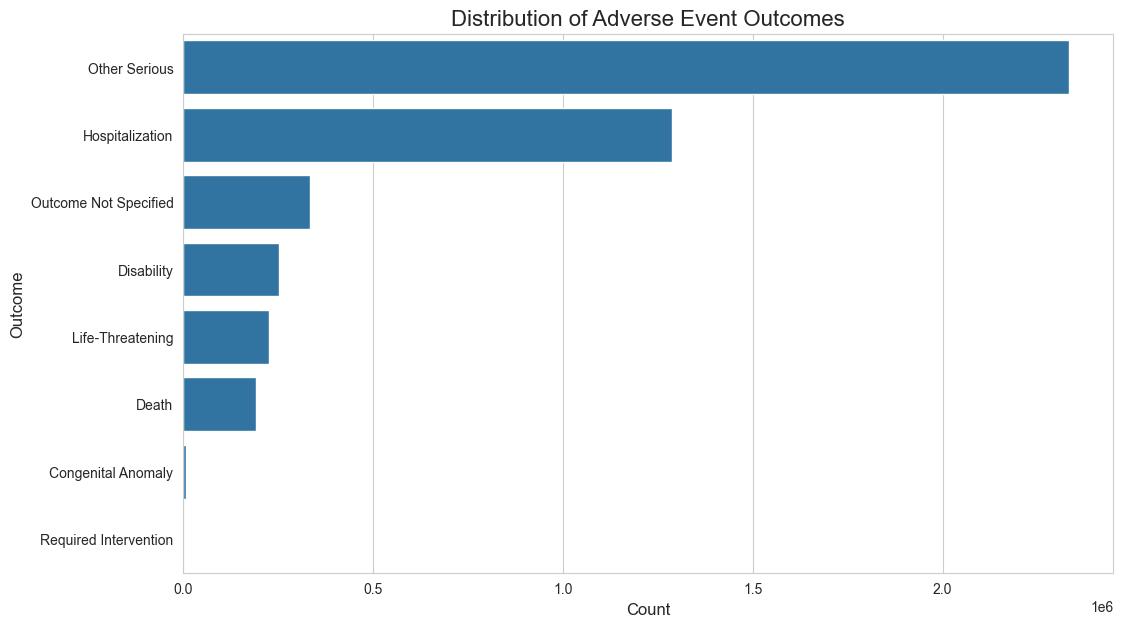

In [4]:
if not df.empty:
    plt.figure(figsize=(12, 7))
    sns.countplot(data=df, y='outcome_code', order=df['outcome_code'].value_counts().index)
    plt.title('Distribution of Adverse Event Outcomes', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Outcome', fontsize=12)
    plt.show()

### Distribution of Patient Age

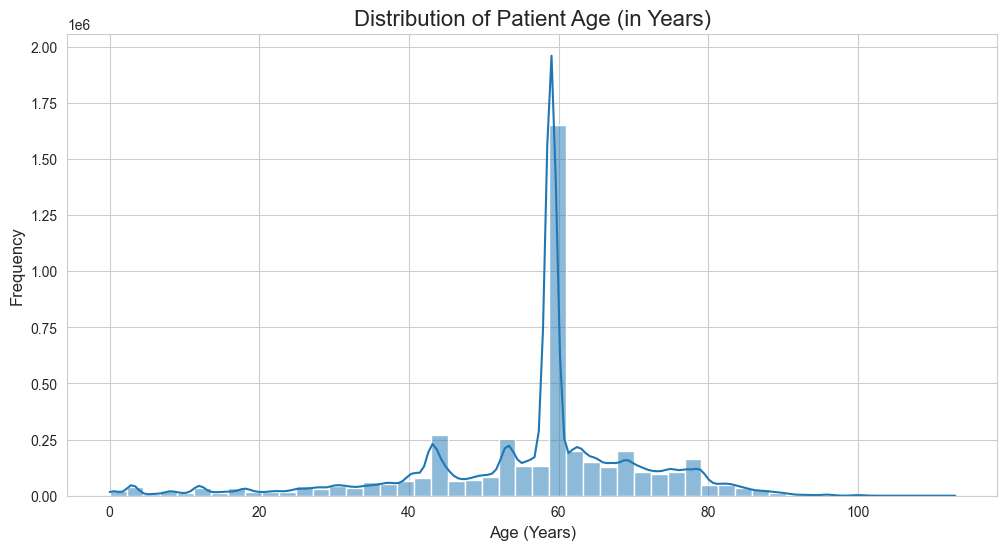

In [5]:
if not df.empty:
    plt.figure(figsize=(12, 6))
    sns.histplot(df['age_in_years'], bins=50, kde=True)
    plt.title('Distribution of Patient Age (in Years)', fontsize=16)
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


# Ignore 59 due to mean imputer

### Report Count by Age Group

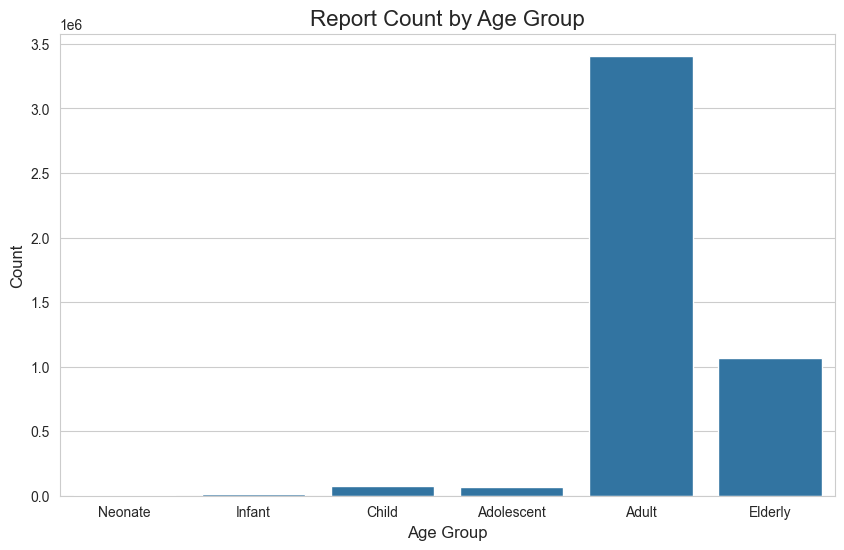

In [6]:
if not df.empty:
    age_order = ['Neonate', 'Infant', 'Child', 'Adolescent', 'Adult', 'Elderly']
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='age_grp', order=age_order)
    plt.title('Report Count by Age Group', fontsize=16)
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

### Report Count by Sex

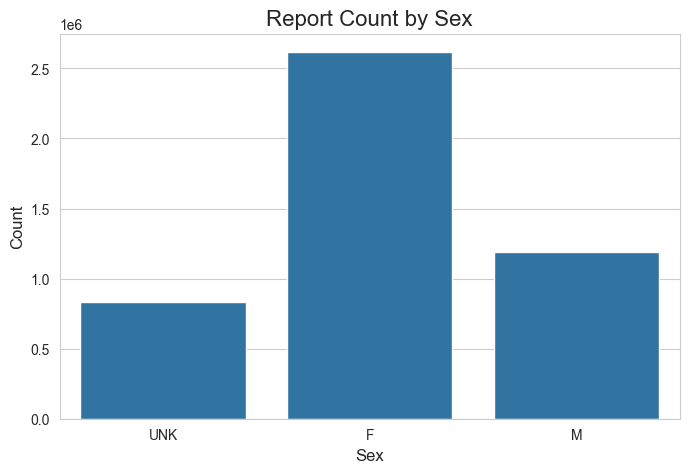

In [17]:
if not df.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='sex')
    plt.title('Report Count by Sex', fontsize=16)
    plt.xlabel('Sex', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

# UNK is unkown

### Top 20 Most Common Adverse Reactions

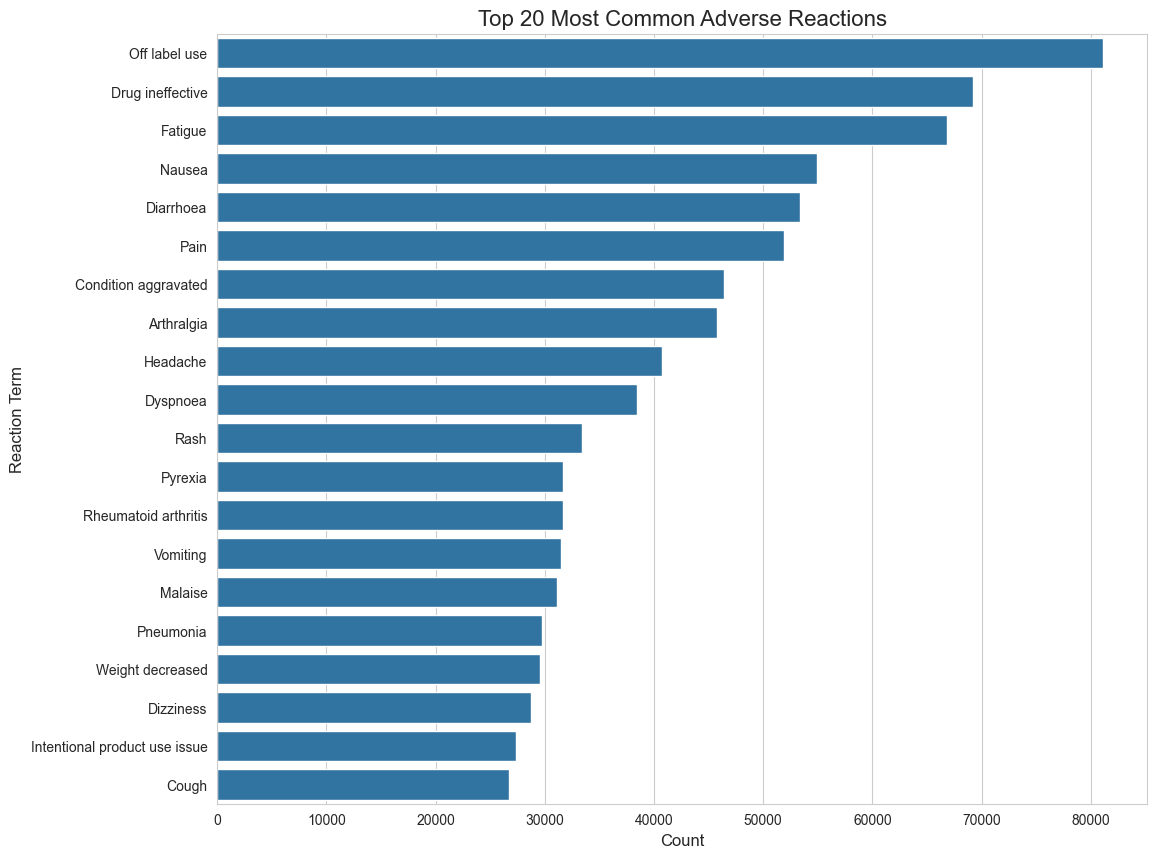

In [8]:
if not df.empty:
    # Get the top 20 most frequent reactions
    top_20_reactions = df['reaction_term'].value_counts().nlargest(20)
    
    plt.figure(figsize=(12, 10))
    sns.barplot(x=top_20_reactions.values, y=top_20_reactions.index)
    plt.title('Top 20 Most Common Adverse Reactions', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Reaction Term', fontsize=12)
    plt.show()

### Top 20 Most Reported Drugs

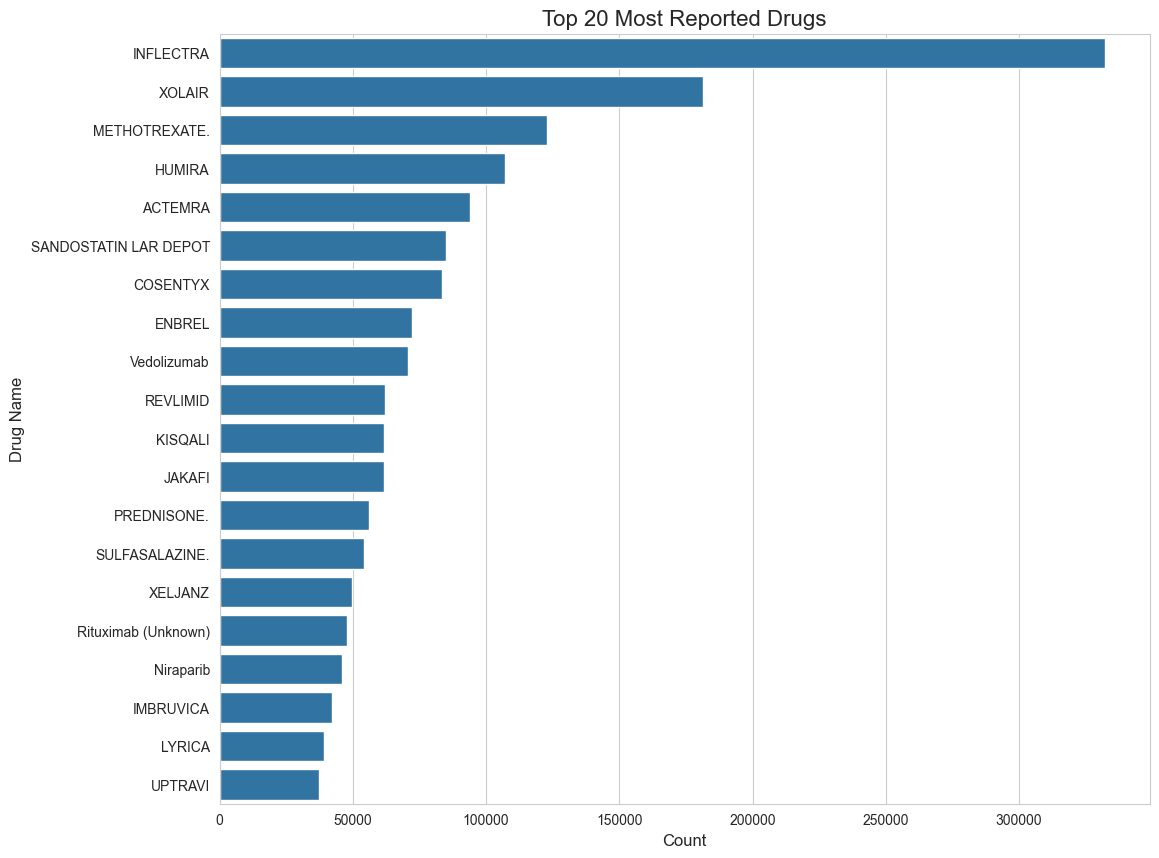

In [9]:
if not df.empty:
    # Get the top 20 most frequent drugs
    top_20_drugs = df['drugname'].value_counts().nlargest(20)
    
    plt.figure(figsize=(12, 10))
    sns.barplot(x=top_20_drugs.values, y=top_20_drugs.index)
    plt.title('Top 20 Most Reported Drugs', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Drug Name', fontsize=12)
    plt.show()

### Report Count by Reporter Type

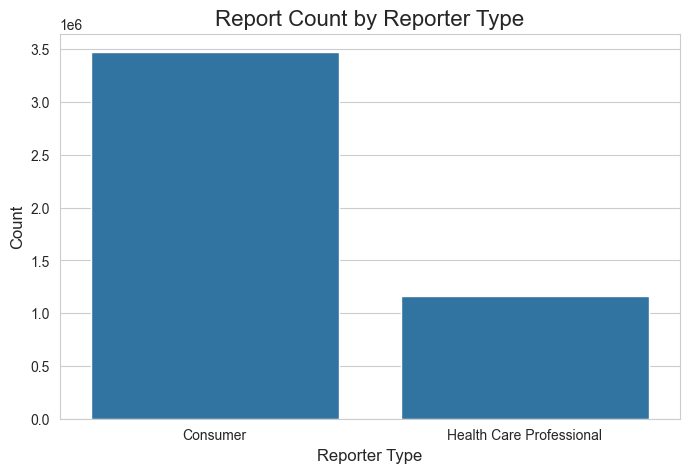

In [10]:
if not df.empty:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='is_hcp')
    plt.title('Report Count by Reporter Type', fontsize=16)
    plt.xlabel('Reporter Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    ax.set_xticklabels(['Consumer', 'Health Care Professional'])
    plt.show()

## Bivariate & Multivariate Analysis

### Proportional Outcome by Age Group

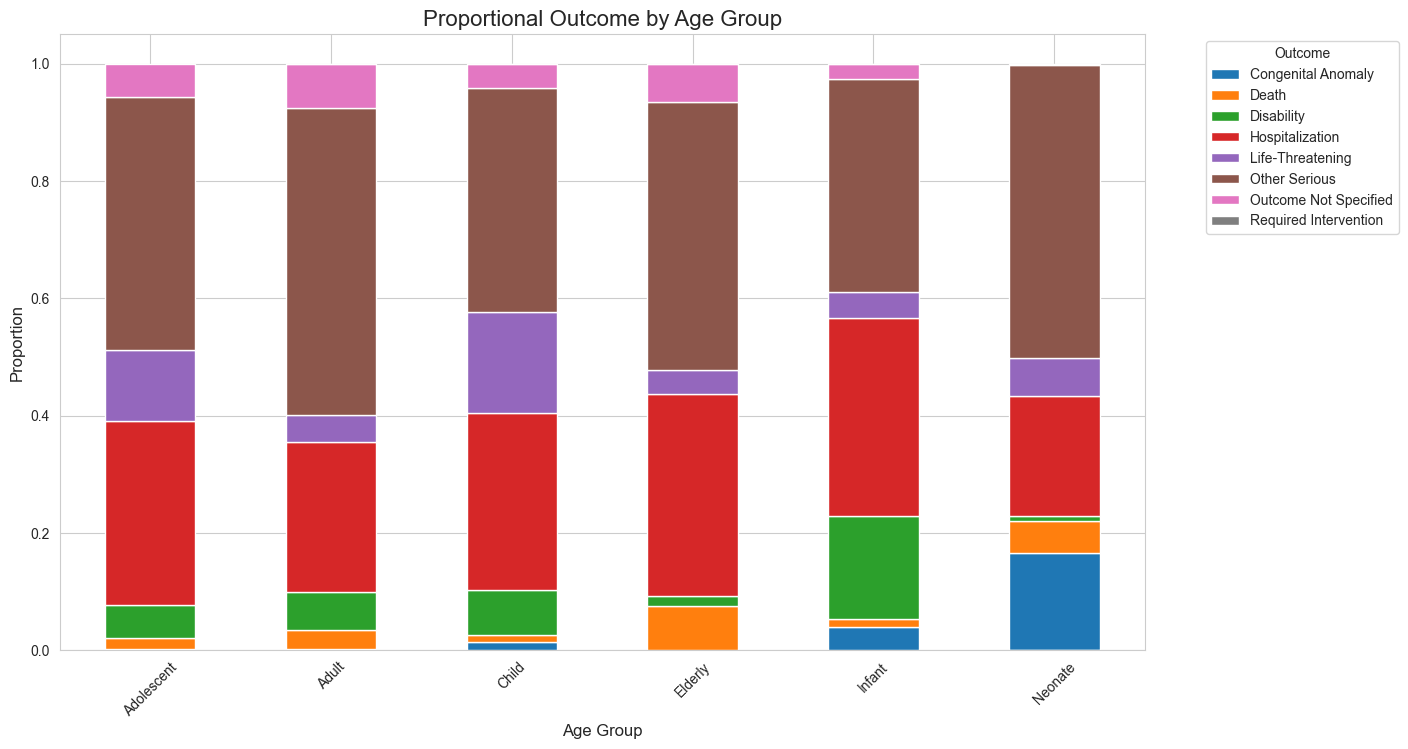

In [18]:
if not df.empty:
    df_grouped = df.groupby('age_grp')['outcome_code'].value_counts(normalize=True).unstack().fillna(0)
    df_grouped.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.title('Proportional Outcome by Age Group', fontsize=16)
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

### Proportional Outcome by Sex

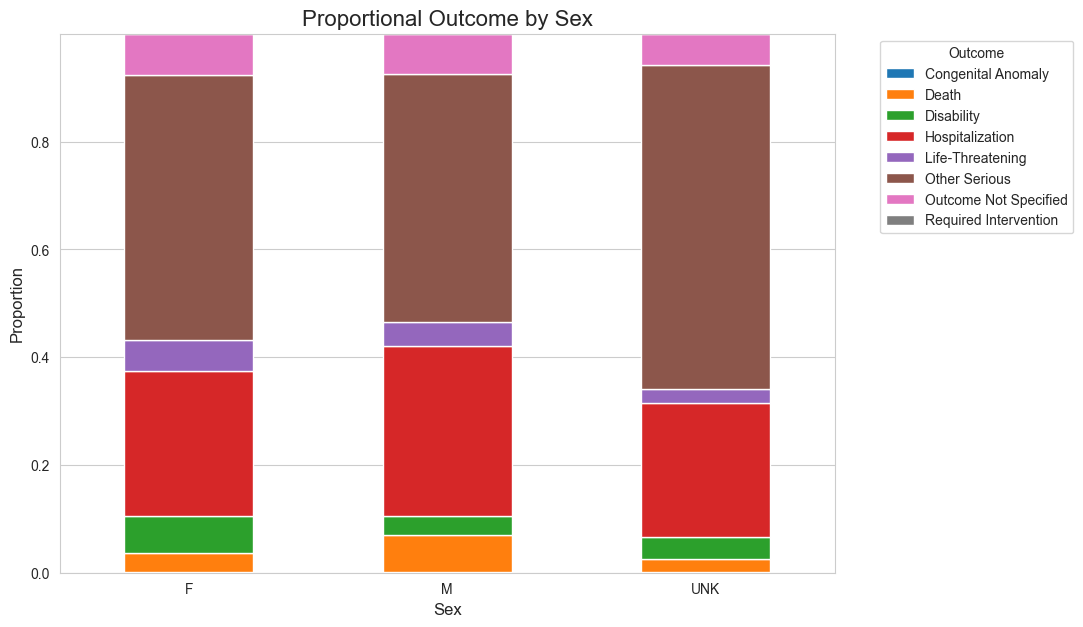

In [12]:
if not df.empty:
    # Calculate proportions
    df_grouped_sex = df.groupby('sex')['outcome_code'].value_counts(normalize=True).unstack().fillna(0)
    
    # Create stacked bar chart
    df_grouped_sex.plot(kind='bar', stacked=True, figsize=(10, 7))
    plt.title('Proportional Outcome by Sex', fontsize=16)
    plt.xlabel('Sex', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

### Outcome Distribution for Top 10 Reported Drugs


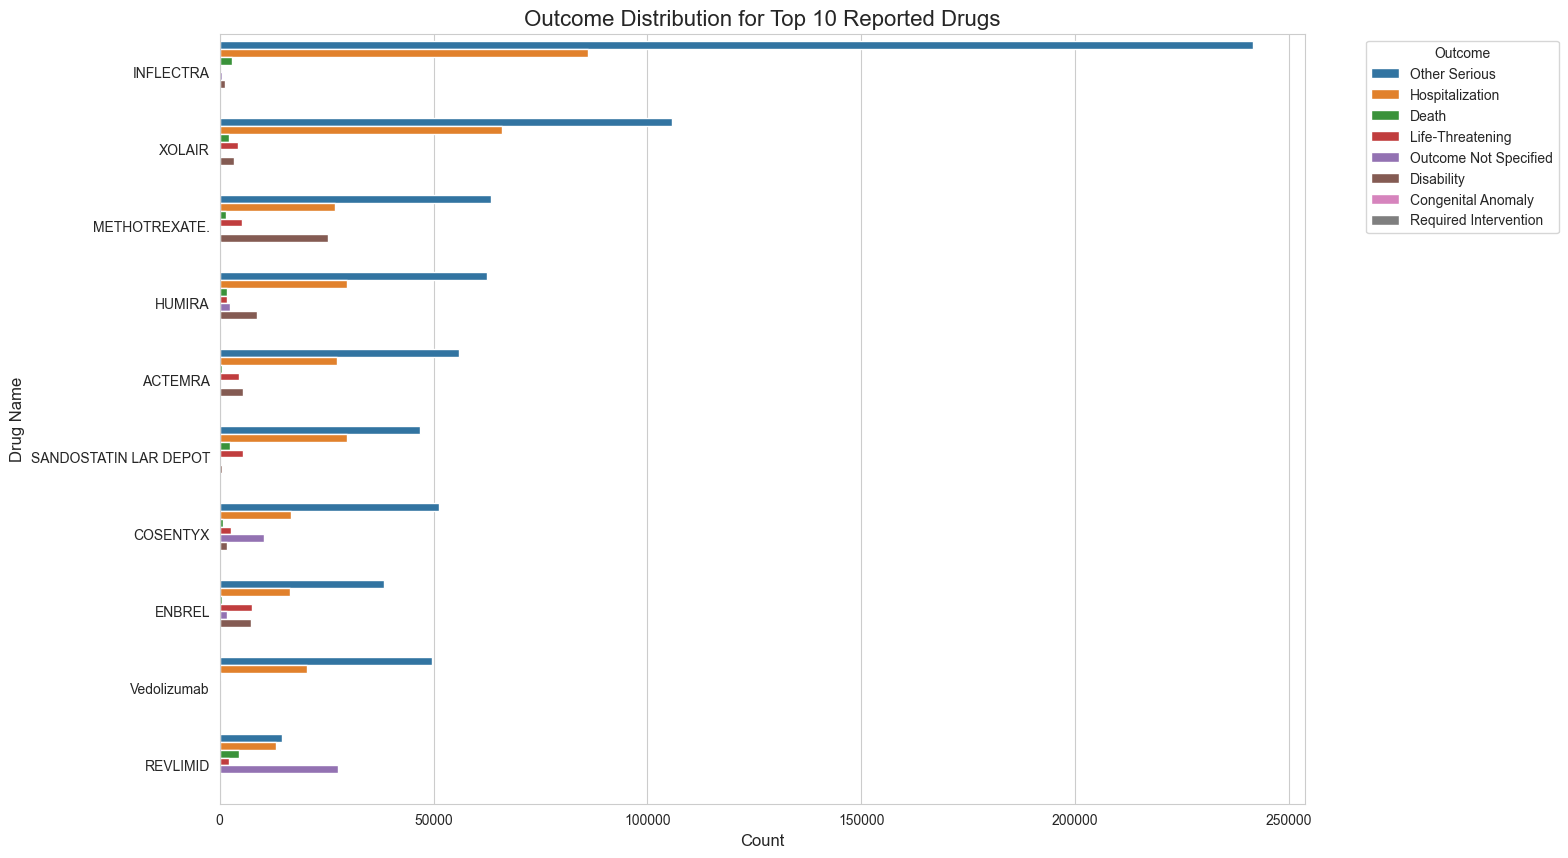

In [13]:
if not df.empty:
    # Get the top 10 drug names
    top_10_drug_names = df['drugname'].value_counts().nlargest(10).index
    
    # Filter the DataFrame to only include these drugs
    df_top_10_drugs = df[df['drugname'].isin(top_10_drug_names)]
    
    plt.figure(figsize=(14, 10))
    sns.countplot(data=df_top_10_drugs, y='drugname', hue='outcome_code', order=top_10_drug_names)
    plt.title('Outcome Distribution for Top 10 Reported Drugs', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Drug Name', fontsize=12)
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

### Age Distribution by Outcome


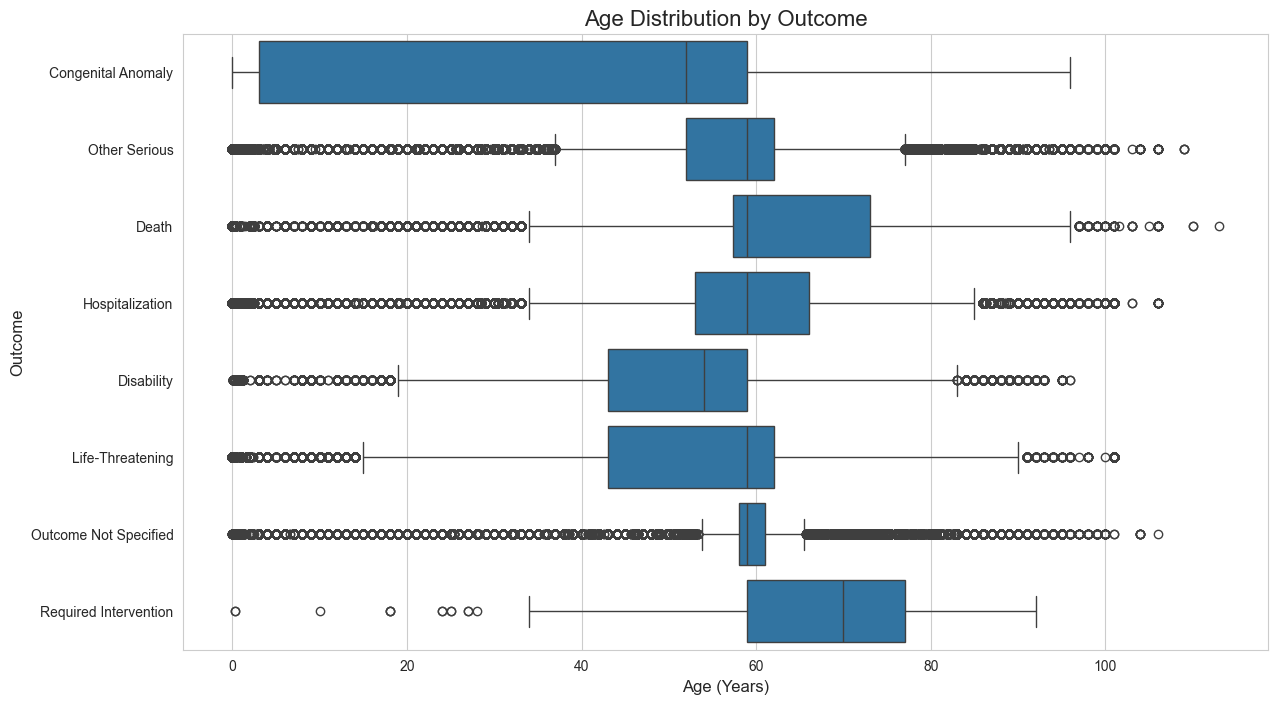

In [14]:
if not df.empty:
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df, x='age_in_years', y='outcome_code')
    plt.title('Age Distribution by Outcome', fontsize=16)
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Outcome', fontsize=12)
    plt.show()

### Proportional Outcome by Reporter Type (HCP vs. Consumer)

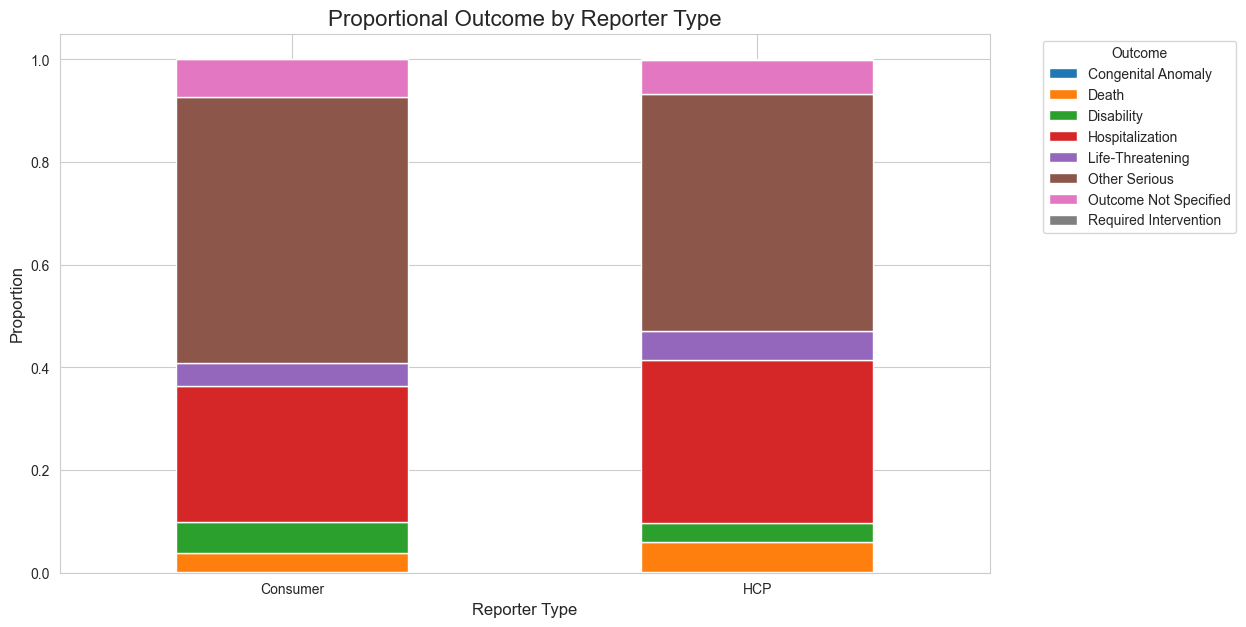

In [15]:
if not df.empty:
    # Calculate proportions
    df_grouped_hcp = df.groupby('is_hcp')['outcome_code'].value_counts(normalize=True).unstack().fillna(0)
    
    # Map index for clear labels
    df_grouped_hcp.index = df_grouped_hcp.index.map({False: 'Consumer', True: 'HCP'})
    
    # Create stacked bar chart
    df_grouped_hcp.plot(kind='bar', stacked=True, figsize=(12, 7))
    plt.title('Proportional Outcome by Reporter Type', fontsize=16)
    plt.xlabel('Reporter Type', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()